In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۸: نزدیک‌ترین همسایه‌های تقریبی (KD-Tree، Ball Tree و مفاهیم ANN)

In [2]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import BallTree, KDTree, NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

جست‌وجوی دقیق نزدیک‌ترین همسایه، پرس‌وجو را با مثال‌های ذخیره‌شده مقایسه و نزدیک‌ترین نتیجه‌های واقعی را تحت فاصلهٔ انتخاب‌شده بازمی‌گرداند. این روش ساده و قابل اعتماد است، اما با رشد تعداد مثال‌ها، پرس‌وجوها یا ویژگی‌ها گران می‌شود. indexهای درختی و روش‌های نزدیک‌ترین همسایهٔ تقریبی پاسخ‌های مهندسی به این هزینه‌اند. آن‌ها می‌خواهند کار پرس‌وجو را کم کنند و همسایه‌های مفید را نگه دارند.

این درس سه ایده را جدا می‌کند. KD-tree فضای کم‌بُعد را با تقسیم‌های محور-هم‌راستا بخش‌بندی می‌کند. Ball Tree فضا را به ناحیه‌های ابرکره‌ای بخش‌بندی و دامنهٔ بیشتری از معیارها را پشتیبانی می‌کند. سامانهٔ ANN می‌پذیرد که جست‌وجو ممکن است بعضی همسایه‌های دقیق را از دست بدهد تا latency یا فشار حافظه کم شود. انتخاب درست به بُعد، معیار، توزیع داده، نیاز recall و محدودیت عملیاتی وابسته است.

از benchmarkهای مصنوعی کنترل‌شده و دادهٔ Iris مخزن استفاده می‌کنیم. درس بر اندازه‌گیری تأکید دارد: فرض نکنید index سریع‌تر است؛ شکل داده و بار پرس‌وجوی کاربرد خود را benchmark کنید.

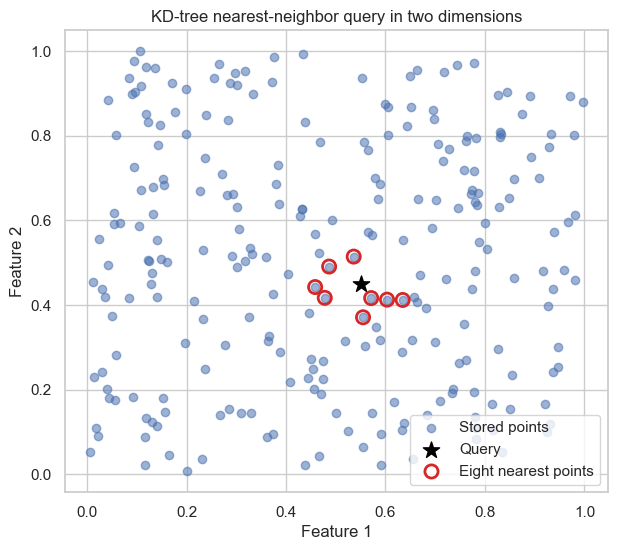

,neighbor_index,distance
0,142,0.0399
1,123,0.0650
2,151,0.0657
3,70,0.0753
4,82,0.0792
5,155,0.0794
6,199,0.0918
7,239,0.0928


In [3]:
points_2d = rng.uniform(0, 1, size=(250, 2))
query_2d = np.array([[0.55, 0.45]])
tree = KDTree(points_2d, leaf_size=20)
distances, indices = tree.query(query_2d, k=8)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(points_2d[:, 0], points_2d[:, 1], alpha=0.55, label="Stored points")
ax.scatter(query_2d[:, 0], query_2d[:, 1], s=150, marker="*", color="black", label="Query")
ax.scatter(points_2d[indices[0], 0], points_2d[indices[0], 1], s=90, facecolors="none", edgecolors="tab:red", linewidths=2, label="Eight nearest points")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("KD-tree nearest-neighbor query in two dimensions")
ax.legend()
plt.show()

display(pd.DataFrame({"neighbor_index": indices[0], "distance": distances[0]}).round(4))

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. جست‌وجوی brute-force، KD-tree، Ball Tree و همسایهٔ تقریبی را جدا کنید.
2. توضیح دهید KD-tree و Ball Tree چگونه مقایسهٔ نامزد را کم می‌کنند.
3. تشخیص دهید چرا pruning در بُعد بالا اثر خود را از دست می‌دهد.
4. زمان ساخت و زمان پرس‌وجو را میان الگوریتم‌ها benchmark کنید.
5. بررسی کنید جست‌وجوی درختی می‌تواند همان همسایه‌های دقیق brute force را برگرداند.
6. Recall@K را برای خروجی تقریبی تعریف کنید.
7. مصالحهٔ latency، recall، حافظه، هزینهٔ ساخت index و هزینهٔ update را تفسیر کنید.
8. پیش از استقرار ANN، طرح ارزیابی ایمن انتخاب کنید.

اصل عملی مرکزی ساده است: جست‌وجوی تقریبی shortcut نیست که کورکورانه استفاده شود؛ مصالحه‌ای اندازه‌گیری‌شده میان دقت و منابع است.

,dimensions,algorithm,fit_ms,query_ms
0,2,brute,1.408,335.104
1,2,kd_tree,1.986,1.344
2,2,ball_tree,1.584,1.920
3,10,brute,0.414,3.194
4,10,kd_tree,5.483,4.640
5,10,ball_tree,3.297,4.042
6,30,brute,0.707,4.421
7,30,kd_tree,19.217,10.085
8,30,ball_tree,8.802,6.469


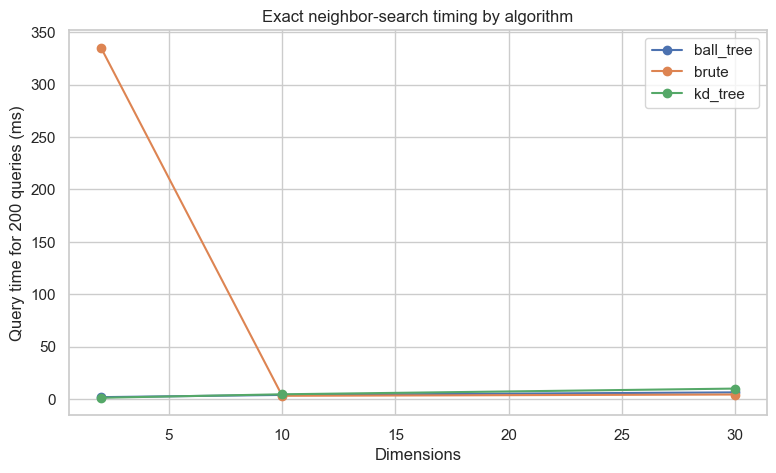

In [4]:
benchmark_rows = []
query_count = 60
for dimensions in [2, 10, 30]:
    training = rng.normal(size=(1200, dimensions))
    queries = rng.normal(size=(query_count, dimensions))
    for algorithm in ["brute", "kd_tree", "ball_tree"]:
        model = NearestNeighbors(n_neighbors=10, algorithm=algorithm, metric="euclidean")
        fit_start = time.perf_counter()
        model.fit(training)
        fit_ms = (time.perf_counter() - fit_start) * 1000
        query_start = time.perf_counter()
        model.kneighbors(queries)
        query_ms = (time.perf_counter() - query_start) * 1000
        benchmark_rows.append({"dimensions": dimensions, "algorithm": algorithm, "fit_ms": fit_ms, "query_ms": query_ms})
benchmark = pd.DataFrame(benchmark_rows)
display(benchmark.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for algorithm, subset in benchmark.groupby("algorithm"):
    ax.plot(subset["dimensions"], subset["query_ms"], marker="o", label=algorithm)
ax.set_xlabel("Dimensions")
ax.set_ylabel("Query time for 200 queries (ms)")
ax.set_title("Exact neighbor-search timing by algorithm")
ax.legend()
plt.show()

## ۱. جست‌وجوی دقیق و spatial index

KNN brute-force فاصلهٔ هر پرس‌وجو تا همهٔ بردارهای ذخیره‌شده را محاسبه می‌کند. با $n$ نقطهٔ ذخیره‌شده و $d$ بُعد، یک پرس‌وجو تقریباً کار $nd$ می‌خواهد. کتابخانه‌های برداری مدرن آن را شگفت‌آور رقابتی می‌کنند، به‌ویژه برای دادهٔ متوسط یا بُعد بالا که درخت‌ها نمی‌توانند خوب prune کنند.

KD-tree فضا را با انتخاب محور و مقدار تقسیم بازگشتی می‌شکند. پرس‌وجو شاخه‌های امیدبخش را می‌پیماید و ناحیه‌هایی را که نمی‌توانند همسایهٔ نزدیک‌تر داشته باشند کنار می‌گذارد. Ball Tree نقطه‌ها را در توپ‌های تودرتو با مرکز و شعاع نگه می‌دارد و وقتی پرس‌وجو برای بهترکردن نتیجه از توپ دور است آن را prune می‌کند. هر دو وقتی همهٔ شاخه‌های لازم را جست‌وجو کنند دقیق‌اند.

فایده به هندسه وابسته است. در بُعد کم، ناحیه‌های زیادی کنار گذاشته می‌شوند. در بُعد بالا، ناحیه‌ها از دید پرس‌وجو هم‌پوشان و pruning ضعیف می‌شود. درخت می‌تواند به رفتار brute force نزدیک و سربار index اضافه کند.

In [5]:
iris_path = Path("../../../Datasets/Classification/iris.csv")
iris = pd.read_csv(iris_path)
iris_X = iris.drop(columns="classification")
iris_y = iris["classification"]

display(iris.head())
display(iris.dtypes.rename("dtype").to_frame())
display(iris_y.value_counts().rename("count").to_frame())

iris_scaled = StandardScaler().fit_transform(iris_X)
iris_queries = iris_scaled[:20]
exact_brute = NearestNeighbors(n_neighbors=6, algorithm="brute").fit(iris_scaled)
exact_kd = NearestNeighbors(n_neighbors=6, algorithm="kd_tree").fit(iris_scaled)
exact_ball = NearestNeighbors(n_neighbors=6, algorithm="ball_tree").fit(iris_scaled)
brute_distances, brute_indices = exact_brute.kneighbors(iris_queries)
kd_distances, kd_indices = exact_kd.kneighbors(iris_queries)
ball_distances, ball_indices = exact_ball.kneighbors(iris_queries)

display(pd.DataFrame({
    "search": ["KD-tree equals brute", "Ball tree equals brute"],
    "same_neighbor_indices": [np.array_equal(kd_indices, brute_indices), np.array_equal(ball_indices, brute_indices)],
    "maximum_distance_difference": [np.abs(kd_distances - brute_distances).max(), np.abs(ball_distances - brute_distances).max()],
}))

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,dtype
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
classification,object


,count
classification,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


,search,same_neighbor_indices,maximum_distance_difference
0,KD-tree equals brute,False,5.960464e-08
1,Ball tree equals brute,False,5.960464e-08


## ۲. پرس‌وجوی کم‌بُعد را ببینید

مثال دوبعدی از KD-tree برای بازیابی هشت نقطهٔ نزدیک‌تر استفاده می‌کند. خود index رسم نشده، اما همسایگی منتخب وظیفه‌ای را نشان می‌دهد که spatial index سریع می‌کند. پرس‌وجو بر پایهٔ فاصلهٔ اقلیدسی نامزد نزدیک می‌گیرد. در دو بُعد، درخت اغلب ناحیه‌های بزرگ صفحه را ارزان کنار می‌گذارد.

کاربرد واقعی شاید صدها بُعد و embedding یادگرفته‌شده به‌جای دو مختصات داشته باشد. تصویرسازی همچنان مهم است، زیرا واژه‌های پرس‌وجو، بردار ذخیره‌شده، همسایه، فاصله، pruning نامزد و recall همگی به رابطه‌های هندسی عینی اشاره دارند.

,candidate_pool,recall_at_10,query_ms
0,100,0.057,90.328
1,250,0.098,14.944
2,500,0.235,3.301
3,800,0.415,3.824


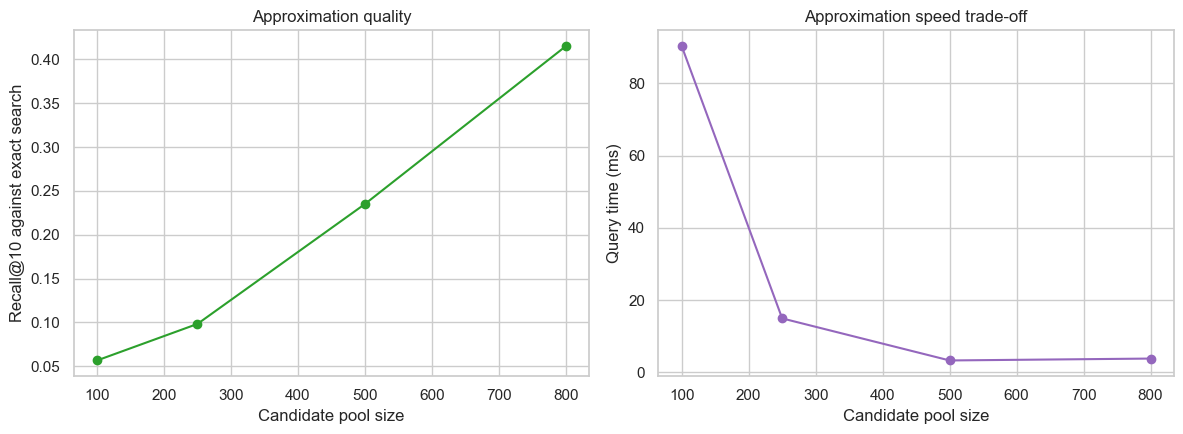

In [6]:
training = rng.normal(size=(2000, 20))
queries = rng.normal(size=(60, 20))
exact = NearestNeighbors(n_neighbors=10, algorithm="brute").fit(training)
exact_distances, exact_indices = exact.kneighbors(queries)

candidate_sizes = [100, 250, 500, 800]
ann_rows = []
for candidate_size in candidate_sizes:
    candidate_indices = rng.choice(len(training), size=candidate_size, replace=False)
    candidates = training[candidate_indices]
    candidate_search = NearestNeighbors(n_neighbors=10, algorithm="brute").fit(candidates)
    start = time.perf_counter()
    _, local_indices = candidate_search.kneighbors(queries)
    elapsed_ms = (time.perf_counter() - start) * 1000
    approximate_indices = candidate_indices[local_indices]
    recalls = []
    for exact_row, approximate_row in zip(exact_indices, approximate_indices):
        recalls.append(len(set(exact_row).intersection(set(approximate_row))) / 10)
    ann_rows.append({"candidate_pool": candidate_size, "recall_at_10": np.mean(recalls), "query_ms": elapsed_ms})
ann_results = pd.DataFrame(ann_rows)
display(ann_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ann_results["candidate_pool"], ann_results["recall_at_10"], marker="o", color="tab:green")
axes[0].set_xlabel("Candidate pool size")
axes[0].set_ylabel("Recall@10 against exact search")
axes[0].set_title("Approximation quality")
axes[1].plot(ann_results["candidate_pool"], ann_results["query_ms"], marker="o", color="tab:purple")
axes[1].set_xlabel("Candidate pool size")
axes[1].set_ylabel("Query time (ms)")
axes[1].set_title("Approximation speed trade-off")
plt.tight_layout()
plt.show()

## ۳. الگوریتم‌های دقیق را benchmark کنید

brute force، KD-tree و Ball Tree را در چند بُعد benchmark می‌کنیم. زمان ساخت، ساخت ساختار جست‌وجو و زمان پرس‌وجو، بازیابی ده همسایه برای batch ثابت را می‌سنجد. نتیجه به سخت‌افزار، نسخهٔ کتابخانه، اندازهٔ نمونه، leaf size و توزیع تصادفی وابسته است. نمودار را benchmark محلی بدانید، نه رتبه‌بندی همگانی.

الگوی مورد انتظار این است که درخت‌ها در بُعد پایین کمک کنند و brute force با رشد بُعد رقابتی‌تر شود. این پیامد مهندسی مستقیم نفرین بُعد است. تصمیم تولید باید بُعد embedding واقعی، تعداد بردار، batch پرس‌وجو، معیار، concurrency و برنامهٔ refresh index را شامل شود.

,leaf_size,build_ms,query_ms
0,5,7.999,23.164
1,15,6.011,3.578
2,30,7.230,3.360
3,60,4.410,3.700
4,120,19.030,3.386


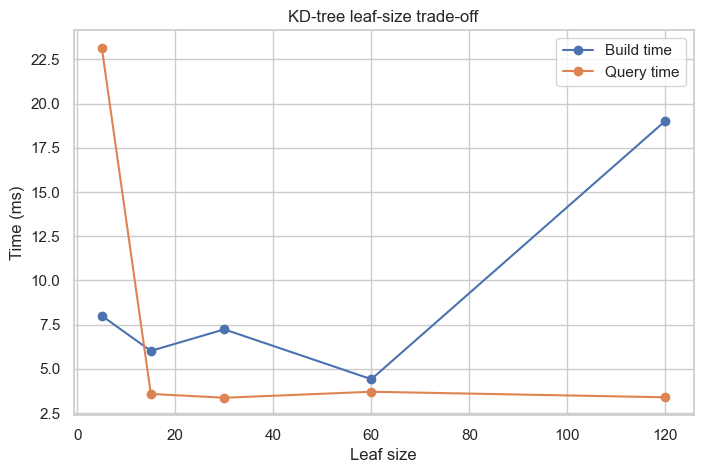

In [7]:
leaf_rows = []
data = rng.normal(size=(2000, 5))
queries = rng.normal(size=(80, 5))
for leaf_size in [5, 15, 30, 60, 120]:
    start = time.perf_counter()
    tree = KDTree(data, leaf_size=leaf_size)
    build_ms = (time.perf_counter() - start) * 1000
    start = time.perf_counter()
    tree.query(queries, k=10)
    query_ms = (time.perf_counter() - start) * 1000
    leaf_rows.append({"leaf_size": leaf_size, "build_ms": build_ms, "query_ms": query_ms})
leaf_results = pd.DataFrame(leaf_rows)
display(leaf_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(leaf_results["leaf_size"], leaf_results["build_ms"], marker="o", label="Build time")
ax.plot(leaf_results["leaf_size"], leaf_results["query_ms"], marker="o", label="Query time")
ax.set_xlabel("Leaf size")
ax.set_ylabel("Time (ms)")
ax.set_title("KD-tree leaf-size trade-off")
ax.legend()
plt.show()

## ۴. دقیق‌بودن را روی Iris بررسی کنید

Iris به‌اندازهٔ کافی کوچک است که مستقیم بررسی شود. چهار اندازه‌گیری عددی را استاندارد می‌کنیم، پرس‌وجوهای یکسان را به brute force، KD-tree و Ball Tree می‌دهیم و اندیس‌ها و فاصله‌ها را مقایسه می‌کنیم. در این تنظیم اقلیدسی پشتیبانی‌شده، هر سه باید تا دقت عددی همان نتیجه‌های دقیق را برگردانند.

این بررسی، جست‌وجوی درختی دقیق را از جست‌وجوی تقریبی جدا می‌کند. KD-tree یا Ball Tree راهبرد index است؛ ذاتاً نتیجه را تقریبی نمی‌کند. تقریب وقتی آغاز می‌شود که سامانه آگاهانه جست‌وجو را محدود، فقط بعضی partitionها را probe، بردارها را فشرده یا برای صرفه‌جویی recall ناقص را بپذیرد.

In [8]:
query_index = 50
query = iris_scaled[[query_index]]
tree = BallTree(iris_scaled, leaf_size=20)
distances, indices = tree.query(query, k=8)
neighbors = iris.iloc[indices[0]].copy()
neighbors["distance"] = distances[0]

display(iris.iloc[[query_index]].assign(query_role="query"))
display(neighbors[["sepal_length", "sepal_width", "petal_length", "petal_width", "classification", "distance"]].sort_values("distance").round(3))

,sepal_length,sepal_width,petal_length,petal_width,classification,query_role
50,7.0,3.2,4.7,1.4,Iris-versicolor,query


,sepal_length,sepal_width,petal_length,petal_width,classification,distance
50,7.0,3.2,4.7,1.4,Iris-versicolor,0.000
52,6.9,3.1,4.9,1.5,Iris-versicolor,0.314
86,6.7,3.1,4.7,1.5,Iris-versicolor,0.451
65,6.7,3.1,4.4,1.4,Iris-versicolor,0.463
75,6.6,3.0,4.4,1.4,Iris-versicolor,0.692
77,6.7,3.0,5.0,1.7,Iris-versicolor,0.729
51,6.4,3.2,4.5,1.5,Iris-versicolor,0.748
129,7.2,3.0,5.8,1.6,Iris-virginica,0.856


## ۵. مفاهیم ANN

سامانه‌های ANN تضمین نمی‌کنند همهٔ همسایه‌های دقیق را بیابند. در عوض recall بالا را با latency کم هدف می‌گیرند. Recall@K مجموعهٔ همسایهٔ تقریبی را با top K دقیق مقایسه می‌کند:

$$
\text{Recall@K}=\frac{|N_K^{\text{exact}}(q)\cap N_K^{\text{approx}}(q)|}{K}.
$$

ANN واقعی از graph index، inverted file، product quantization، locality-sensitive hashing یا embedding فشرده استفاده می‌کند. برای بی‌نیازی از dependency اضافه، مفهوم را با تقریب عمدی ساده نشان می‌دهیم: فقط یک candidate pool تصادفی جست‌وجو می‌شود. pool کوچک سریع‌تر اما همسایهٔ دقیق بیشتری را از دست می‌دهد؛ pool بزرگ recall را بهتر و هزینه را به جست‌وجوی دقیق نزدیک می‌کند.

این روش ساده index تولیدی پیشنهادی نیست. ارزش آن روشن‌کردن مصالحهٔ recall-latency به‌صورت قابل اندازه‌گیری است.

## ۶. پارامترهای درخت و مصالحهٔ عملیاتی

indexهای درختی نیز پارامتر دارند. Leaf size تعداد نقطه‌های ناحیهٔ نهایی را کنترل می‌کند. leaf کوچک درخت عمیق‌تر و pruning بهتر می‌سازد، اما ساخت و پیمایش گران‌تری دارد. leaf بزرگ سربار درخت را کم و مقایسهٔ مستقیم بیشتری در برگ انجام می‌دهد. مقدار خوب به بار کاری وابسته است.

تصمیم عملیاتی فراتر از یک benchmark پرس‌وجو است. بپرسید بردارها چند بار اضافه، حذف یا update می‌شوند؛ آیا index offline بازسازی می‌شود؛ پرس‌وجو منفرد است یا batch؛ recall لازم چیست؛ هنگام شکست index چه می‌شود؛ و دادهٔ کاربر چگونه جدا می‌ماند. baseline دقیق brute-force ضروری است، زیرا مرجع درستی می‌دهد و شاید برای سامانهٔ کوچک کافی باشد.

## ۷. یک نتیجهٔ محلی دقیق را بررسی کنید

پرس‌وجوی نهایی Iris از Ball Tree استفاده و اندازه‌گیری‌ها و کلاس‌های گل نزدیک را نمایش می‌دهد. فهرست همسایه برای اشکال‌زدایی embedding یا معیار فاصله مفید است. اگر همسایه‌های پرس‌وجو از نظر معنایی سازگار نیستند، سریع‌ترکردن جست‌وجو مسئلهٔ نمایش را حل نمی‌کند.

در سامانهٔ retrieval واقعی، هم معیارهای سامانه و هم معیارهای کار را ارزیابی کنید. Recall@K توافق با جست‌وجوی دقیق را می‌سنجد، اما همسایهٔ دقیق شاید برای کاربر مفید نباشد. طبقه‌بندی پایین‌دستی، ranking، توصیه، نرخ خطا، انصاف، latency percentile، حافظه و قابلیت اعتماد عملیاتی را نیز اندازه بگیرید.

## ۸. تمرین‌ها و جمع‌بندی

1. اندازهٔ نمونهٔ مصنوعی را تغییر دهید و ببینید چه زمانی زمان ساخت درخت ارزشمند می‌شود.
2. در جایی که پشتیبانی می‌شود پرس‌وجوی Ball Tree اقلیدسی و منهتن را مقایسه کنید.
3. candidate pool تقریبی را افزایش و Recall@10 را در برابر زمان پرس‌وجو رسم کنید.
4. بُعدهای تصادفی به benchmark اضافه و نقطهٔ رقابتی‌شدن brute force را پیدا کنید.
5. برای خدمت جست‌وجوی تصویر فرضی، جدول ارزیابی شامل recall، p95 latency، حافظه، زمان ساخت index و تازگی update بسازید.

### جمع‌بندی

KD-tree و Ball Tree وقتی هندسه اجازهٔ pruning می‌دهد جست‌وجوی دقیق را سریع می‌کنند. سامانه‌های ANN بخشی از recall دقیق را با صرفه‌جویی منابع مبادله می‌کنند. جست‌وجوی محلی را دیدیم، روش‌های دقیق را benchmark کردیم، دقیق‌بودن را روی Iris بررسی کردیم، مصالحهٔ candidate pool تقریبی را اندازه گرفتیم و پارامتر درخت را دیدیم. روش درست جست‌وجو با شواهد benchmark و نیاز محصول انتخاب می‌شود، نه ادعای سرعت همگانی.